1. ПЕРЕГЛЯД СТРУКТУРИ ТА ПЕРШИХ РЯДКІВ ДАНИХ
      conflict_name                  conflict_type       region  start_year  \
0      WWII (Japan)                      World War    East Asia        1939   
1  Israel-Hamas War                 Asymmetric War  Middle East        2023   
2  Syrian Civil War                      Civil War  Middle East        2011   
3    WWII (Germany)                      World War       Europe        1939   
4   Afghanistan War  Interstate/Counter-insurgency   South Asia        2001   

   end_year    status   primary_country  pre_war_unemployment_pct  \
0      1945  Resolved             Japan                      7.49   
1      2026   Ongoing  Palestine (Gaza)                      8.18   
2      2026   Ongoing             Syria                     12.70   
3      1945  Resolved           Germany                     14.06   
4      2021  Resolved       Afghanistan                      5.38   

   during_war_unemployment_pct  unemployment_spike_percentage_poi

C:\Users\day2026\AppData\Local\Temp\ipykernel_6812\1917738365.py:65: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns


                                            count          mean           std  \
start_year                               100000.0  1.999401e+03  2.995715e+01   
end_year                                 100000.0  2.009040e+03  3.055218e+01   
pre_war_unemployment_pct                 100000.0  9.017027e+00  3.458406e+00   
during_war_unemployment_pct              100000.0  2.262520e+01  1.381829e+01   
unemployment_spike_percentage_points     100000.0  1.360818e+01  1.196018e+01   
youth_unemployment_change_pct            100000.0  1.768676e+01  1.567821e+01   
pre_war_poverty_rate_pct                 100000.0  1.751882e+01  7.217439e+00   
during_war_poverty_rate_pct              100000.0  2.907719e+01  1.300078e+01   
extreme_poverty_rate_pct                 100000.0  1.455354e+01  7.487060e+00   
food_insecurity_rate_pct                 100000.0  2.035121e+01  9.790643e+00   
households_fallen_into_poverty_estimate  100000.0  1.597617e+05  9.355617e+05   
gdp_change_pct              

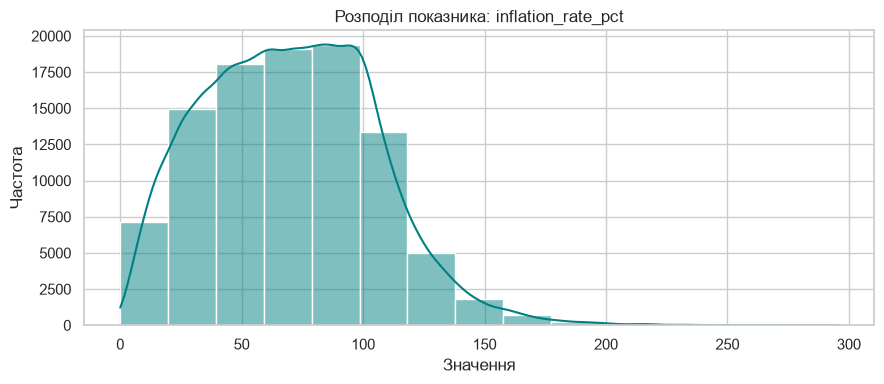

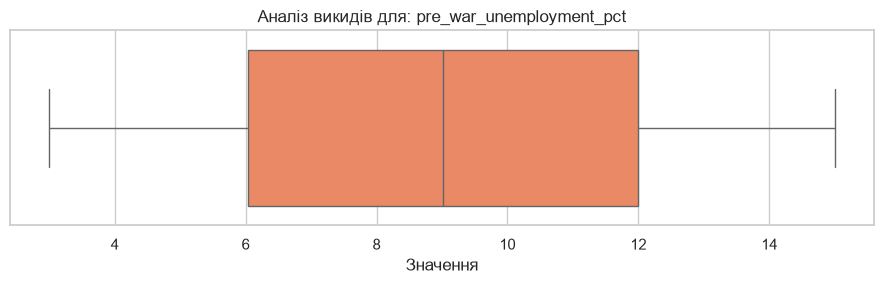

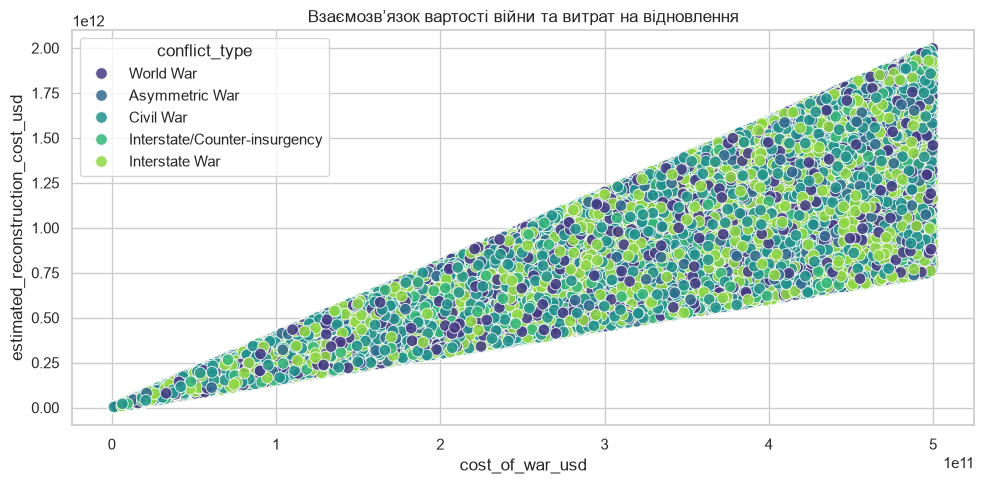


5. МАТРИЦЯ КОРЕЛЯЦІЙ


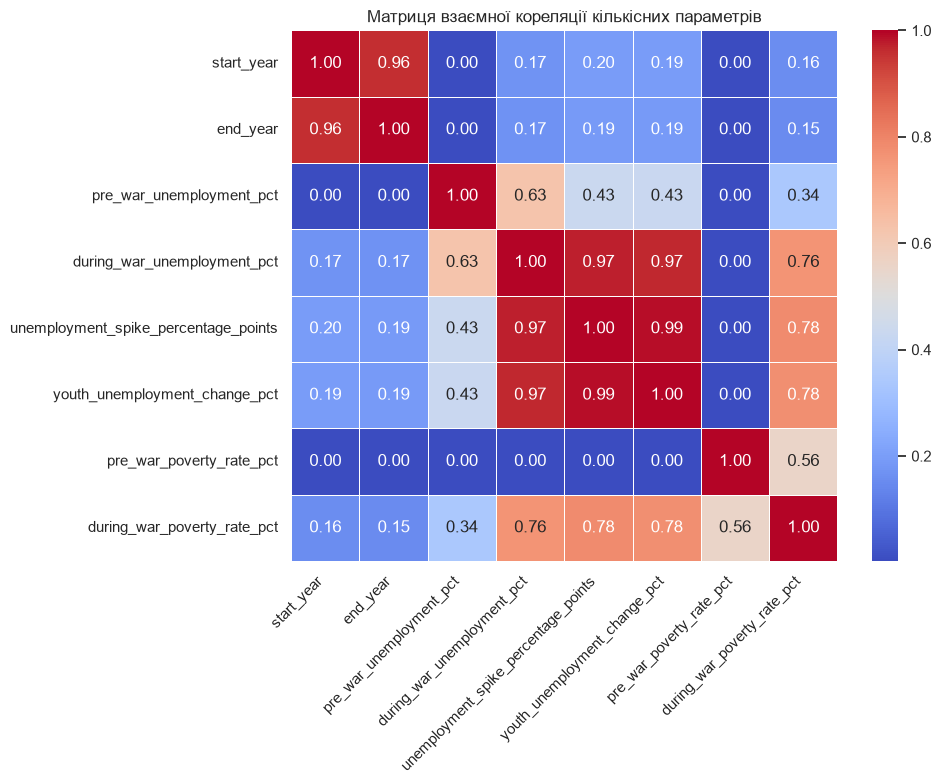


Аналіз завершено успішно.


In [27]:
# ==============================================================================
# ПРАКТИЧНА РОБОТА: АНАЛІЗ НАБОРУ ДАНИХ З KAGGLE
# Тема: Економічні наслідки збройних конфліктів
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування стилю для графіків
sns.set_theme(style="whitegrid")
plt.rcParams['figure.autolayout'] = True


# ==============================================================================
# ЕТАП 3: ЗАВАНТАЖЕННЯ ТА ПЕРЕГЛЯД ДАНИХ
# ==============================================================================
# Шлях до локального файлу з даними
file_path = r'C:\Users\day2026\Documents\IAZprak\war_economic_impact_dataset.csv'

# Зчитування файлу у DataFrame
df = pd.read_csv(file_path)

# Нормалізація назв колонок: прибираємо пробіли, робимо малі літери, 
# а символ '%' замінюємо на 'pct', щоб уникнути конфліктів у коді
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace('%', 'pct', regex=False)
    .str.replace(' ', '_', regex=False)
)

print("=" * 60)
print("1. ПЕРЕГЛЯД СТРУКТУРИ ТА ПЕРШИХ РЯДКІВ ДАНИХ")
print("=" * 60)
print(df.head())

print("\n--- Загальна інформація про стовпці та типи даних ---")
df.info()


# ==============================================================================
# ЕТАП 4: ОЧИЩЕННЯ ТА ОБРОБКА ДАНИХ
# ==============================================================================
print("\n" + "=" * 60)
print("2. ОЧИЩЕННЯ ТА ПІДГОТОВКА ДАНИХ")
print("=" * 60)

# Перевірка наявності пропущених значень
print("Кількість пропусків у кожній колонці:")
print(df.isnull().sum())

# Видалення повних дублікатів (якщо є)
duplicates_count = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f"\nВидалено дублікатів: {duplicates_count}")

# Заповнення пропусків середнім значенням для числових колонок
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Перетворення категоріальних змінних у числові коди
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    df[f"{col}_code"] = df[col].astype('category').cat.codes

print("Категоріальні змінні успішно закодовано у суфікси '_code'.")
print("Розмірність датасету після очищення:", df.shape)


# ==============================================================================
# ЕТАП 5: ОПИСОВА СТАТИСТИКА
# ==============================================================================
print("\n" + "=" * 60)
print("3. ОСНОВНІ СТАТИСТИЧНІ ПОКАЗНИКИ (ОПИСОВА СТАТИСТИКА)")
print("=" * 60)
# Вивід: count, mean (середнє), std (стандартне відхилення), min, 25%, 50% (медіана), 75%, max
print(df.describe().T)


# ==============================================================================
# ЕТАП 6: ВІЗУАЛІЗАЦІЯ ДАНИХ
# ==============================================================================
print("\n" + "=" * 60)
print("4. ГЕНЕРАЦІЯ ВІЗУАЛІЗАЦІЙ")
print("=" * 60)

# 1. Гістограма з кривою щільності (KDE) для інфляції
inflation_col = next((c for c in df.columns if 'inflation' in c), None)
if inflation_col:
    plt.figure(figsize=(9, 4))
    sns.histplot(data=df, x=inflation_col, bins=15, kde=True, color='teal')
    plt.title(f'Розподіл показника: {inflation_col}', fontsize=12)
    plt.xlabel('Значення')
    plt.ylabel('Частота')
    plt.show()

# 2. Коробкова діаграма (Boxplot) для аналізу аномалій / викидів
spike_col = next((c for c in df.columns if 'spike' in c or 'unemployment' in c), None)
if spike_col:
    plt.figure(figsize=(9, 3))
    sns.boxplot(data=df, x=spike_col, color='coral')
    plt.title(f'Аналіз викидів для: {spike_col}', fontsize=12)
    plt.xlabel('Значення')
    plt.show()

# 3. Діаграма розсіювання (Scatterplot) між двома кількісними змінними
cost_col = next((c for c in df.columns if 'cost_of_war' in c), None)
recon_col = next((c for c in df.columns if 'reconstruction' in c), None)
type_col = next((c for c in df.columns if 'conflict_type' in c and not c.endswith('_code')), None)

if cost_col and recon_col:
    plt.figure(figsize=(10, 5))
    sns.scatterplot(
        data=df, 
        x=cost_col, 
        y=recon_col, 
        hue=type_col if type_col else None,
        palette='viridis',
        s=70, 
        alpha=0.85
    )
    plt.title('Взаємозв’язок вартості війни та витрат на відновлення', fontsize=12)
    plt.xlabel(cost_col)
    plt.ylabel(recon_col)
    plt.show()


# ==============================================================================
# ЕТАП 7: КОРЕЛЯЦІЙНИЙ АНАЛІЗ
# ==============================================================================
print("\n" + "=" * 60)
print("5. МАТРИЦЯ КОРЕЛЯЦІЙ")
print("=" * 60)

# Відбираємо вихідні числові ознаки (виключаємо створені технічні коди для читабельності)
pure_numeric = [c for c in df.select_dtypes(include=[np.number]).columns if not c.endswith('_code')][:8]
corr_matrix = df[pure_numeric].corr()

# Візуалізація теплової карти (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5, 
    cbar=True
)
plt.title('Матриця взаємної кореляції кількісних параметрів', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

print("\nАналіз завершено успішно.")